In [1]:
import sys
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

# Make project root importable so that "src" can be found
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.config import (
    REGION,
    LOW_PRICE_THRESHOLD,
    ROLLING_WINDOW_MONTHS,
    MIN_HISTORY_MONTHS,
    STALE_RETURN_THRESHOLD,
)
from src.paths import get_project_paths, ensure_project_directories
from src.loaders import load_raw_datasets
from src.cleaning import (
    prepare_price_data,
    prepare_market_caps_data,
    prepare_carbon_data,
    apply_low_price_filter,
    compute_returns,
    apply_delisting_returns,
)
from src.universe import build_universe_by_year
from src.optimization import compute_mv_weights_by_year
from src.backtest import run_mv_backtest
from src.benchmark import run_vw_backtest
from src.reporting import (
    build_performance_table,
    compute_cumulative_series,
    plot_cumulative_performance,
    export_part1_outputs,
)

In [2]:
paths = get_project_paths()
ensure_project_directories(paths)

BASE_DIR = paths["BASE_DIR"]
DATA_RAW = paths["DATA_RAW"]
DATA_PROCESSED = paths["DATA_PROCESSED"]
OUTPUTS = paths["OUTPUTS"]
TABLES_DIR = paths["TABLES_DIR"]
FIGURES_DIR = paths["FIGURES_DIR"]
INTERMEDIATE_DIR = paths["INTERMEDIATE_DIR"]

static, prices_raw, market_caps_raw, carbon_raw = load_raw_datasets(DATA_RAW)

print("Project root detected at:", BASE_DIR)
print("Static shape:", static.shape)
print("Prices raw shape:", prices_raw.shape)
print("Market caps raw shape:", market_caps_raw.shape)
print("Carbon raw shape:", carbon_raw.shape)

Project root detected at: /Users/victorrelvapereira/Desktop/SAAM_PROJECT_SRC
Static shape: (2545, 4)
Prices raw shape: (2609, 316)
Market caps raw shape: (2609, 316)
Carbon raw shape: (2609, 29)


In [3]:
# Regional universe
em_firms = static[static["Region"] == REGION].copy()
em_isins = em_firms["ISIN"].tolist()

# Prepare core datasets
price_data = prepare_price_data(prices_raw, em_isins)
price_data = apply_low_price_filter(price_data, LOW_PRICE_THRESHOLD)

market_caps_data = prepare_market_caps_data(market_caps_raw, em_isins)
carbon_data = prepare_carbon_data(carbon_raw, em_isins)

# Compute monthly returns and apply delisting treatment
returns_matrix = compute_returns(price_data)
returns_matrix = apply_delisting_returns(price_data, returns_matrix)

print("Number of firms in regional universe:", len(em_isins))
print("Price data shape:", price_data.shape)
print("Market caps data shape:", market_caps_data.shape)
print("Carbon data shape:", carbon_data.shape)
print("Returns matrix shape:", returns_matrix.shape)
print("Returns exactly -100%:", (returns_matrix.stack() == -1).sum())

Number of firms in regional universe: 702
Price data shape: (702, 314)
Market caps data shape: (702, 314)
Carbon data shape: (702, 27)
Returns matrix shape: (702, 314)
Returns exactly -100%: 62


In [4]:
rebalance_years = list(range(2014, 2026))

universe_by_year = build_universe_by_year(
    returns_matrix=returns_matrix,
    price_data=price_data,
    carbon_data=carbon_data,
    rebalance_years=rebalance_years,
    rolling_window_months=ROLLING_WINDOW_MONTHS,
    min_history_months=MIN_HISTORY_MONTHS,
    stale_return_threshold=STALE_RETURN_THRESHOLD,
)

mv_weights_by_year = compute_mv_weights_by_year(
    returns_matrix=returns_matrix,
    universe_by_year=universe_by_year,
    rebalance_years=rebalance_years,
    rolling_window_months=ROLLING_WINDOW_MONTHS,
)

print("Universe sizes:")
for year in rebalance_years:
    print(f"{year}: {len(universe_by_year[year])} firms")

print("\n2014 MV portfolio:")
print("Number of firms in 2014 MV portfolio:", len(mv_weights_by_year[2014]))
print("Sum of weights in 2014:", mv_weights_by_year[2014].sum())
mv_weights_by_year[2014].head()

Universe sizes:
2014: 254 firms
2015: 278 firms
2016: 309 firms
2017: 345 firms
2018: 389 firms
2019: 424 firms
2020: 472 firms
2021: 511 firms
2022: 546 firms
2023: 573 firms
2024: 584 firms
2025: 568 firms

2014 MV portfolio:
Number of firms in 2014 MV portfolio: 254
Sum of weights in 2014: 1.0000000000000002


ISIN
BRBBASACNOR3    1.778407e-18
BRBBDCACNPR8    9.894483e-19
BRBRFSACNOR8    0.000000e+00
BRBRKMACNPA4    0.000000e+00
BRCESPACNPB4    2.214627e-18
dtype: float64

In [5]:
mv_returns_by_year, mv_returns_oos = run_mv_backtest(
    returns_matrix=returns_matrix,
    mv_weights_by_year=mv_weights_by_year,
    rebalance_years=rebalance_years,
)

vw_returns_by_year, vw_returns_oos = run_vw_backtest(
    returns_matrix=returns_matrix,
    market_caps_data=market_caps_data,
    universe_by_year=universe_by_year,
    rebalance_years=rebalance_years,
)

print("MV OOS shape:", mv_returns_oos.shape)
print("MV first date:", mv_returns_oos.index.min())
print("MV last date:", mv_returns_oos.index.max())
print("MV total cumulative return:", (1 + mv_returns_oos).prod() - 1)

print("\nVW OOS shape:", vw_returns_oos.shape)
print("VW first date:", vw_returns_oos.index.min())
print("VW last date:", vw_returns_oos.index.max())
print("VW total cumulative return:", (1 + vw_returns_oos).prod() - 1)

MV OOS shape: (144,)
MV first date: 2014-01-31 00:00:00
MV last date: 2025-12-31 00:00:00
MV total cumulative return: 1.3956355485428888

VW OOS shape: (144,)
VW first date: 2014-01-31 00:00:00
VW last date: 2025-12-31 00:00:00
VW total cumulative return: 1.2918006638928738


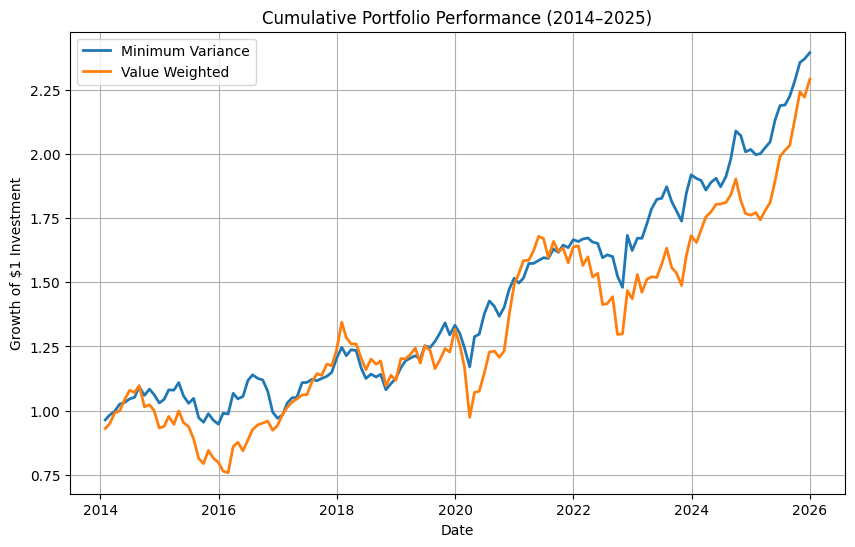

Performance table:


,Portfolio,Annualized Return,Annualized Volatility,Sharpe Ratio,Minimum Monthly Return,Maximum Monthly Return,Total Cumulative Return
0,Minimum Variance,0.078752,0.108075,0.728680,-0.074699,0.136727,1.395636
1,Value Weighted,0.081563,0.156772,0.520267,-0.167606,0.134429,1.291801



Figure saved at: /Users/victorrelvapereira/Desktop/SAAM_PROJECT_SRC/outputs/figures/cumulative_portfolio_performance.png
Figure exists: True

Exported files:
mv_returns_oos -> /Users/victorrelvapereira/Desktop/SAAM_PROJECT_SRC/outputs/tables/mv_returns_oos.csv | exists: True
vw_returns_oos -> /Users/victorrelvapereira/Desktop/SAAM_PROJECT_SRC/outputs/tables/vw_returns_oos.csv | exists: True
performance_summary -> /Users/victorrelvapereira/Desktop/SAAM_PROJECT_SRC/outputs/tables/portfolio_performance_summary.csv | exists: True


In [6]:
performance = build_performance_table(
    mv_returns_oos=mv_returns_oos,
    vw_returns_oos=vw_returns_oos,
)

mv_cumulative, vw_cumulative = compute_cumulative_series(
    mv_returns_oos=mv_returns_oos,
    vw_returns_oos=vw_returns_oos,
)

figure_path = plot_cumulative_performance(
    mv_cumulative=mv_cumulative,
    vw_cumulative=vw_cumulative,
    figures_dir=FIGURES_DIR,
    show_plot=True,
)

exported_paths = export_part1_outputs(
    mv_returns_oos=mv_returns_oos,
    vw_returns_oos=vw_returns_oos,
    performance=performance,
    tables_dir=TABLES_DIR,
)

print("Performance table:")
display(performance)

print("\nFigure saved at:", figure_path)
print("Figure exists:", figure_path.exists())

print("\nExported files:")
for name, path in exported_paths.items():
    print(name, "->", path, "| exists:", path.exists())

In [8]:
from openpyxl import load_workbook
from openpyxl.drawing.image import Image as XLImage
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# ---------------------------------------------------------
# Helper: annualized cumulative return
# ---------------------------------------------------------
def annualized_cumulative_return(return_series):
    n_months = len(return_series.dropna())
    total_cum_return = (1 + return_series).prod() - 1
    return (1 + total_cum_return) ** (12 / n_months) - 1

# ---------------------------------------------------------
# Helper: create single-portfolio cumulative plot
# ---------------------------------------------------------
def save_single_cumulative_plot(series, title, output_path):
    plt.figure(figsize=(5, 3.2))
    plt.plot(series, linewidth=2)
    plt.title(title)
    plt.ylabel("Growth of $1")
    plt.xlabel("Date")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.close()

# ---------------------------------------------------------
# Paths
# ---------------------------------------------------------
template_path = BASE_DIR / "Template for Part I-SAAM.xlsx"
filled_template_path = OUTPUTS / "Part_I_template_filled.xlsx"

vw_plot_path = FIGURES_DIR / "vw_cumulative_template_plot.png"
mv_plot_path = FIGURES_DIR / "mv_cumulative_template_plot.png"

# ---------------------------------------------------------
# Build cumulative series if not already in memory
# ---------------------------------------------------------
mv_cumulative, vw_cumulative = compute_cumulative_series(
    mv_returns_oos=mv_returns_oos,
    vw_returns_oos=vw_returns_oos,
)

# Create two single-portfolio plots for the template
save_single_cumulative_plot(
    vw_cumulative,
    "Value-Weighted Portfolio",
    vw_plot_path
)

save_single_cumulative_plot(
    mv_cumulative,
    "Minimum Variance Portfolio",
    mv_plot_path
)

# ---------------------------------------------------------
# Load workbook
# ---------------------------------------------------------
wb = load_workbook(template_path)
ws = wb["Sheet1"]

# ---------------------------------------------------------
# Fill portfolio characteristics
# Template layout:
# B = Value-weighted
# C = Minimum variance
# Rows 3:8 are the metrics
# ---------------------------------------------------------
vw_ann_return = vw_returns_oos.mean() * 12
mv_ann_return = mv_returns_oos.mean() * 12

vw_ann_vol = vw_returns_oos.std() * (12 ** 0.5)
mv_ann_vol = mv_returns_oos.std() * (12 ** 0.5)

vw_ann_cum = annualized_cumulative_return(vw_returns_oos)
mv_ann_cum = annualized_cumulative_return(mv_returns_oos)

vw_sharpe = vw_ann_return / vw_ann_vol
mv_sharpe = mv_ann_return / mv_ann_vol

vw_min = vw_returns_oos.min()
mv_min = mv_returns_oos.min()

vw_max = vw_returns_oos.max()
mv_max = mv_returns_oos.max()

# Row mapping
ws["B3"] = vw_ann_return
ws["C3"] = mv_ann_return

ws["B4"] = vw_ann_vol
ws["C4"] = mv_ann_vol

ws["B5"] = vw_ann_cum
ws["C5"] = mv_ann_cum

ws["B6"] = vw_sharpe
ws["C6"] = mv_sharpe

ws["B7"] = vw_min
ws["C7"] = mv_min

ws["B8"] = vw_max
ws["C8"] = mv_max

# ---------------------------------------------------------
# Fill monthly portfolio returns
# Template:
# E column = date
# F = Value-weighted
# G = Minimum variance
#
# We align by year-month because template dates are month-start
# while our returns index is month-end.
# ---------------------------------------------------------
vw_map = {pd.Timestamp(d).to_period("M"): v for d, v in vw_returns_oos.items()}
mv_map = {pd.Timestamp(d).to_period("M"): v for d, v in mv_returns_oos.items()}

for row in range(3, ws.max_row + 1):
    cell_date = ws[f"E{row}"].value
    if isinstance(cell_date, pd.Timestamp):
        period = cell_date.to_period("M")
    elif hasattr(cell_date, "year") and hasattr(cell_date, "month"):
        period = pd.Timestamp(cell_date).to_period("M")
    else:
        continue

    ws[f"F{row}"] = vw_map.get(period, None)
    ws[f"G{row}"] = mv_map.get(period, None)

# ---------------------------------------------------------
# Insert plots
# Template placeholders are in B9 and C9
# We insert VW plot in B9 and MV plot in C9
# ---------------------------------------------------------
img_vw = XLImage(str(vw_plot_path))
img_mv = XLImage(str(mv_plot_path))

# Resize for template
img_vw.width = 260
img_vw.height = 170

img_mv.width = 260
img_mv.height = 170

ws.add_image(img_vw, "B9")
ws.add_image(img_mv, "C9")

# ---------------------------------------------------------
# Save filled template
# ---------------------------------------------------------
wb.save(filled_template_path)

print("Filled template saved at:")
print(filled_template_path)

Filled template saved at:
/Users/victorrelvapereira/Desktop/SAAM_PROJECT_SRC/outputs/Part_I_template_filled.xlsx
